# TO DO:
- fare tutti i markdown in bella
- aggiungere "bibliografia" in fondo con link documentation: alla fine e link "[ ]" oppure link direttamente nel markdown? (a lucry piace di più la bibliografia alla fine e i link [] tipo paper :) )
- magari salviamo l'immagine finale con tutta la roba per tutte le immagini così lo riesce a vedere al volo che viene per tutte senza dover modificare il nome e runnare dodici volte il codice


[comandi per formattare i markdown](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)


### Image Processing and Computer Vision - Project
## CAP INSPECTION - Project 1 : Plastic cup liner inspection
### *Lucrezia Ponti, Thomas Vespignani*

**Project objective:** Locate the defects in the liner of a plastic cup.  

#### Tasks:
1. **Cap segmentation and defect detection**<br>
   **1.1** Outline the cap by generating a circle that fits the cap mouth and record the following information:  
   - the position of the center of the cap;  
   - the diameter of the cap mouth;  

   **1.2** Find if the liner is missing and if it is not, find if the liner has a defect; 

2. **Liner segmentation**<br>
   Outline the liner by generating a circle that fits the liner border and record the following information:  
   - the position of the center of the liner;  
   - the diameter of the liner;  

**Optional requirement:**<br>
Outline the straight edge of the liner's defect.

### Code Setup

In [392]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

liner_flag = False
defect_flag = False
final_results= ""

To make the code more flexible, in this section two variables can be modified to choose:
- the image to be inspected (*img_name*) 
- whether to show all the intermediate results of the computations (show_step= True) or only the final results of each task (show_steps = False)

In [393]:
img_name = "d_18"
show_steps = True

The image is loaded as colored, which is useful to efficiently show the results, but since for the functions used in the computation a grayscale image is required, we create a copy as such.

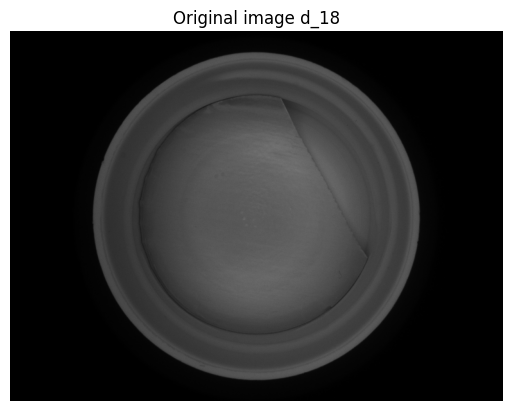

In [394]:
img_color = cv2.imread("cap-inspection-images/project_1_liner_inspection/"+img_name+".bmp")
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
if show_steps :
    plt.figure()
    plt.title("Original image "+img_name)
    plt.imshow(img,cmap='gray',vmin=0,vmax=255)
    plt.axis('off')
    plt.show()

## Enhancing the image
In many Computer Vision applications an initial step of image processing is often added to improve the quality of the image and enhance the details useful for the specific objectives. <br>

In this case, it can be oberved that the gray-scale histogram of the images is generally confined to a small range (about [0;100]), see Figure below.

Since we have to inspect the gradient to perform the computations, it proved useful to enlarge the histogram range and therefore improve the contrast of the image. <br>
To do this, the Contrast Limited Adaptive Histogram Equalization (CLAHE) is used [[Documentation](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html)].
This function divides the image into "tiles", whose size is set with the parameter *tileGridSize*, and for each performs a linear histogram equalization. To avoid amplifying noise, a limit on the contrast is applied: for each tile's histogram, before applying the equalization, if any bin has value above the limit (specified with the parameter *clipLimit*) it is clipped and the excess is redistribuited uniformly to other bins. Finally, to remove artifacts in tile borders, bilinear interpolation is applied.

We obtain an image with a better distributed histogram, without amplifying noise or creating artifacts.

<div style="display: flex;justify-content: center; gap: 10px;">
    <img src="report_pictures/d_18.png" alt="image d_18" height="220"/>
    <img src="report_pictures/hist_d_18.png" alt="histogram of image d_18" height="220"/>
    <img src="report_pictures/hist_d_18_clahe.png" alt="enhanced histogram of image d_18" height="220"/>
</div>

Additionally, to remove noise and becuse it is needed for the Canny edge detector used in the following steps, a Gaussian filter is applied.

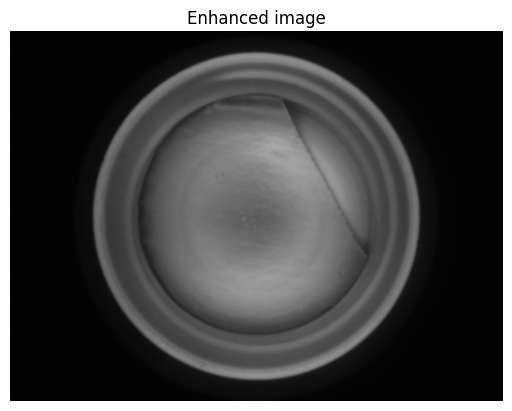

In [395]:

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5,5))
img_cl = clahe.apply(img)
img_blur = cv2.GaussianBlur(img_cl,(7,7),1.5)

if show_steps :
    plt.figure()
    plt.title("Enhanced image")
    plt.imshow(img_blur,cmap="gray",vmin=0,vmax=255)
    plt.axis('off')
    plt.show()

## Task 1: Cap segmentation and defect detection


### 1.1 Segmentation of the cap mouth
Following the hint given, the function HoughCircles is used to detect the cap mouth [[Documentation](https://docs.opencv.org/4.x/dd/d1a/group__imgproc__feature.html#ga47849c3be0d0406ad3ca45db65a25d2d)]. 

The function applies Canny edge detector as a first step and applies the Hough Transform theory applied to circles. This theory uses the analytical equation of the circles, which has 3 parameters, therefore it would require a 3D accumulator, which is highly inefficient. Instead the Hough Gradient Method is used, which is trickier but more efficient.<br>
The most important parameters of the function are: 
- *minDist*: minimum distance between the centers of the detected circles;
- *param1*: higher threshold of the Canny edge detector (the lower one is its half);
- *param2*:	accumulator threshold for the circle centers at the detection stage, the smaller it is, the more false circles may be detected.

In particular, *param1* is chosen to 110 so that Canny will only find the cap mouth outer contur, which has a very strong gradient, and not other edges inside.

The HoughCircles function returns a list of all the detected circles, containing each circle's center position and radius, sorted in descending order based on their accumulator value. Therefore, the first circle in the list corresponds to the most accurate detection of the cap mouth contour.

CAP MOUTH OUTLINE 
 Center: x =  382.5  y =  287.5  
 Diameter =  509.2


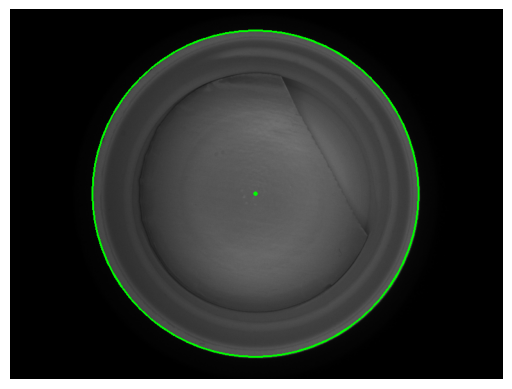

In [396]:
circles_out = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 40,param1=110,param2=80) 
center_out = (circles_out[0][0][0],circles_out[0][0][1])
radius_out = circles_out[0][0][2]

img_color_out=img_color.copy()
cv2.circle(img_color_out,(int(center_out[0]),int(center_out[1])),int(radius_out),color=(0, 255, 0),thickness=2)
cv2.circle(img_color_out,(int(center_out[0]),int(center_out[1])),int(2),color=(0, 255, 0),thickness=2)

print("CAP MOUTH OUTLINE \n Center: x = ", center_out[0]," y = ",center_out[1]," \n Diameter = ",radius_out*2 )
plt.imshow(img_color_out)
plt.axis('off')
plt.show()


img_color_final=img_color.copy() # to use for all steps
cv2.circle(img_color_final,(int(center_out[0]),int(center_out[1])),int(radius_out),color=(0, 255, 0),thickness=2)
cv2.circle(img_color_final,(int(center_out[0]),int(center_out[1])),int(2),color=(0, 255, 0),thickness=2)
final_results=final_results+"CAP MOUTH OUTLINE\n Center: x = "+str(center_out[0])+" y = "+str(center_out[1])+" - Diameter = "+str(radius_out*2) + " \n"


### 1.2 Liner inspection
To get clearer information about the liner, it is useful to consider only a Region Of Interest inside the cap mouth. 
The dimension of the ROI has been chosen empirically to be a fraction of the radius of the cap mouth obtained in the previous step, so that the liner area is shown properly. 

Fistly, we need to find whether the liner is present or not. <br>
Following the hint given, the average lightness of each image should be inspected. Doing so it can be observed that for caps with the liner this value is about 97 and for caps without the liner (image d_31) it is about 107. Therefore, a threshold value con be fixed, to 102, to evaluate the average lightness and use it to validate the presence of the liner. This could be implemented as such:
```
avg=cv2.mean(img_roi)[0]
if avg>102 : 
    print("NO LINER")
else : 
    # continue computation
```

However, considering to evaluate only one image at a time, it may be better to find a method that does not rely so heavily on other images' information. 

We observed that when the liner is present it creates a darker shadow at its border, which can easily be detected as edge.
By applying the HoughCircles function with param1 = 100, which is more permissive than the value used for cap mouth detection, the edge map obtained with Canny shows the liner contour if present, therefore a circle is detected. If no liner is present the shadow is not as dark and therefore no circle is found. <br>
This allows us to also find immediately the infomation about the liner needed for the second task. 

<div style="display: flex;justify-content: center; gap: 10px;">
    <img src="report_pictures/canny_liner_d_18.png" alt="edge map of d_18" height="250"/>
    <img src="report_pictures/canny_liner_d_31.png" alt="edge map of d_31" height="250"/>
</div>


### se il liner c'è trova se c'è difetti 
facciamo manualmente canny (che inspecta il magnitude of the gradient) e poi houghlines (perche lui in automatico non lo fa a differenza di houghcircles)

se trova linee vuol dire che c'è il difetto altrimenti no difetto
prendiamo la prima linea dato ceh tanto le tira fuori in ordine decrescente del valore dell'accomulatore (cioe ordine di "perfezione")

[LINK UTILE PER SPIEGAZIONE HOUGHLINES](https://learnopencv.com/hough-transform-with-opencv-c-python/)

LINER FOUND


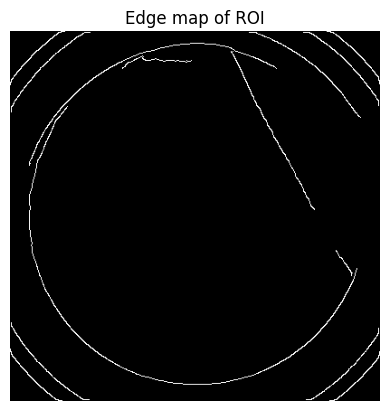

LINER DEFECT FOUND


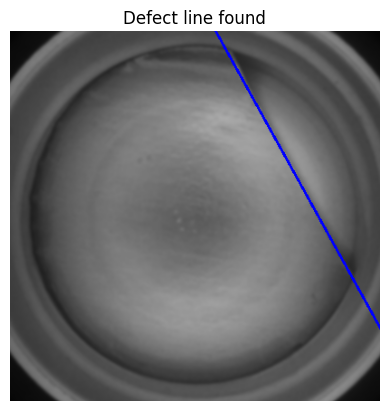

In [397]:
offset = radius_out*0.8 
x_max_roi=math.ceil(center_out[0]+offset)
x_min_roi=math.floor(center_out[0]-offset)
y_max_roi=math.ceil(center_out[1]+offset)
y_min_roi=math.floor(center_out[1]-offset)  
img_roi=img_blur[y_min_roi:y_max_roi,x_min_roi:x_max_roi]
img_roi_show=cv2.cvtColor(img_roi, cv2.COLOR_GRAY2RGB) 


circles_in = cv2.HoughCircles(img_roi,cv2.HOUGH_GRADIENT, 1, 50,param1=100,param2=80) 

line_layer=np.zeros_like(img_color) # useful for the optional requirement

if circles_in is not None and len(circles_in) > 0: 
    
    print("LINER FOUND")
    liner_flag= True

    edges = cv2.Canny(img_roi,40,80,apertureSize = 3)
    if show_steps :
        plt.figure()
        plt.title("Edge map of ROI")
        plt.imshow(edges,cmap='gray',vmin=0,vmax=255)
        plt.axis('off')
        plt.show() 
    

    lines = cv2.HoughLines(edges,1,np.pi/180,70)
    if lines is not None and len(lines) > 0:    
        
        print("LINER DEFECT FOUND")
        defect_flag= True

        rho, theta = lines[0][0] 
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(line_layer, (x1+x_min_roi, y1+y_min_roi), (x2+x_min_roi, y2+y_min_roi), (0, 0, 255), 2) # useful for the optional requirement
        
        if show_steps :
            cv2.line(img_roi_show, (x1, y1), (x2, y2), (0, 0, 255), 2)
            plt.figure()
            plt.title("Defect line found")
            plt.imshow(img_roi_show)
            plt.axis('off')
            plt.show()
        
    else: 
        print("NO LINER DEFECTS FOUND") 
        final_results=final_results+"NO LINER DEFECTS FOUND \n"

else : 
    print("NO LINER FOUND") 
    final_results=final_results+"NO LINER FOUND \n"


## Task 2 : Liner segmentation
If the liner is present, its outline has to be shown in the image and the information about the position of its center and its radius has to be recorded.

The information needed for this can be retreived from the results obtained in the previous step, with the function HoughCircles applied on the ROI.<br>
It is important to translate the position of the center back to the coordinatess of the original image to have information coherent with that of the cap mouth.

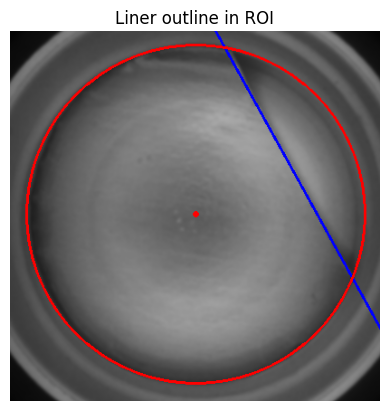

LINER OUTLINE
 Center: x =  383.5  y =  285.5 
 Diameter =  375.8


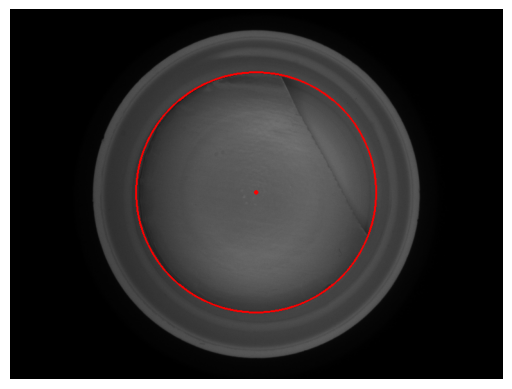

In [398]:
circle_liner_layer=np.zeros_like(img_color) # useful for the optional requirement

if liner_flag: 

    center_in = (circles_in[0][0][0],circles_in[0][0][1])
    radius_in = circles_in[0][0][2]
    
    cv2.circle(circle_liner_layer,(int(center_in[0])+x_min_roi,int(center_in[1])+y_min_roi),int(radius_in),color=(255,0, 0),thickness=2) # useful for the optional requirement

    if show_steps: 
        cv2.circle(img_roi_show,(int(center_in[0]),int(center_in[1])),int(radius_in),color=(255, 0, 0),thickness=2)
        cv2.circle(img_roi_show,(int(center_in[0]),int(center_in[1])),int(2),color=(255,0, 0),thickness=2)
        plt.figure()
        plt.title("Liner outline in ROI")
        plt.imshow(img_roi_show)
        plt.axis('off')
        plt.show()

    img_color_in=img_color.copy()
    cv2.circle(img_color_in,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(radius_in),color=(255, 0, 0),thickness=2)
    cv2.circle(img_color_in,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(2),color=(255, 0, 0),thickness=2)

    print("LINER OUTLINE\n Center: x = ", center_in[0]+x_min_roi," y = ",center_in[1]+y_min_roi,"\n Diameter = ",radius_in*2)
    plt.figure()
    plt.imshow(img_color_in)
    plt.axis('off')
    plt.show()


    cv2.circle(img_color_final,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(radius_in),color=(255, 0, 0),thickness=2)
    cv2.circle(img_color_final,(int(center_in[0]+x_min_roi),int(center_in[1]+y_min_roi)),int(2),color=(255, 0, 0),thickness=2)
    final_results=final_results+"LINER OUTLINE\n Center: x = "+str(center_in[0]+x_min_roi)+" y = "+str(center_in[1]+y_min_roi)+" - Diameter = "+str(radius_in*2) + " \n"



## Optional requirement
Outline the straight edge of the defect of the liner, where present.

In the step 1.2, two dedicated empty images, *cirle_liner_layer* and *line_layer*, were created. <br>
When the line representative of the defect is found, a blue line is added onto *line_layer*, similarly, when the liner contour is found, a red circle is added onto *cirle_liner_layer*. <br>
By combining the two layers we obtain a new image with a blue line, a red circle and pink pixels at their intersection.








lists with some points of which to make sure i only get two that are in the two different intersections i take the first and last <br>
Calculate line length <br>
Calculate perpendicular unit normal vector <br>
Define how wide you want the rectangle to be on each side of the line <br>
Calculate the four corners dynamically<br>
Format the points into an array for OpenCV<br>


ho trovato una domanda di stack overflow che da esattamente questo metodo (in caso ci sospettasse AI) [LINK](https://stackoverflow.com/questions/7854043/drawing-rectangle-between-two-points-with-arbitrary-width) - letteralmente primo risultato cercando "draw rectangle around segment line" su google 

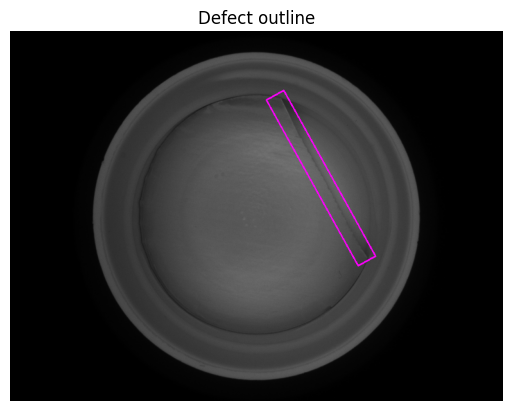

In [399]:
if defect_flag:
    liner_layer=line_layer+circle_liner_layer
    mask = np.all(liner_layer == np.array([255, 0, 255], dtype=np.uint8), axis=2)
    y, x = np.where(mask) 

    x1=x[0]
    y1=y[0]
    x2=x[-1]
    y2=y[-1]

    dx = x2-x1
    dy = y2-y1
    length = math.sqrt(dx**2+dy**2)

    if length>0:
        nx = -dy/length
        ny = dx/length
        
        width = 15
        pt1 = [x1+width*nx, y1+width*ny]
        pt2 = [x1-width*nx, y1-width*ny]
        pt3 = [x2-width*nx, y2-width*ny]
        pt4 = [x2+width*nx, y2+width*ny]
        
        pts = np.array([pt1, pt2, pt3, pt4], dtype=np.int32)
        
        img_color_rect=img_color.copy()
        cv2.polylines(img_color_rect, [pts], isClosed=True, color=(255, 0, 255), thickness=2)
    
        plt.figure()
        plt.title("Defect outline")
        plt.imshow(img_color_rect)
        plt.axis('off')
        plt.show()



        cv2.polylines(img_color_final, [pts], isClosed=True, color=(255, 0, 255), thickness=2)
        final_results=final_results+"DEFECT DETECTED \n"


## Final results 

CAP MOUTH OUTLINE
 Center: x = 382.5 y = 287.5 - Diameter = 509.2 
LINER OUTLINE
 Center: x = 383.5 y = 285.5 - Diameter = 375.8 
DEFECT DETECTED 



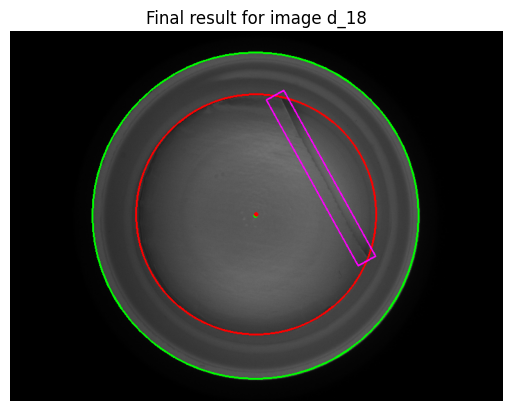

In [400]:
print(final_results)
plt.figure()
plt.title("Final result for image "+img_name)
plt.imshow(img_color_final)
plt.axis('off')
plt.show()

In [ ]:
##################### DA TOGLIERE PRIMA DI CONSEGNARE SERVE SOLO PER SALVARE LE IMMAGINI
'''
save_img = cv2.cvtColor(img_color_final, cv2.COLOR_RGB2BGR)
cv2.imwrite("results-images/results_"+img_name+".jpg", save_img)
'''

True